[2026-07-18 09:50:59] [info     ] 计算因子，区间：2019-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-18 09:52:23] [info     ] 读取因子库，区间：2019-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-18 09:52:23] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-18 09:52:36] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-18 09:52:44] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-18 09:52:57] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2019-01-14 至 2024-12-31
[2026-07-18 09:52:57] [info     ] ========== 数据检查 ==========
[2026-07-18 09:52:57] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2020-02-03~2020-03-31,0.0184
2024-01-15~2024-02-08,-0.0157
2024-09-24~2024-10-08,0.0432

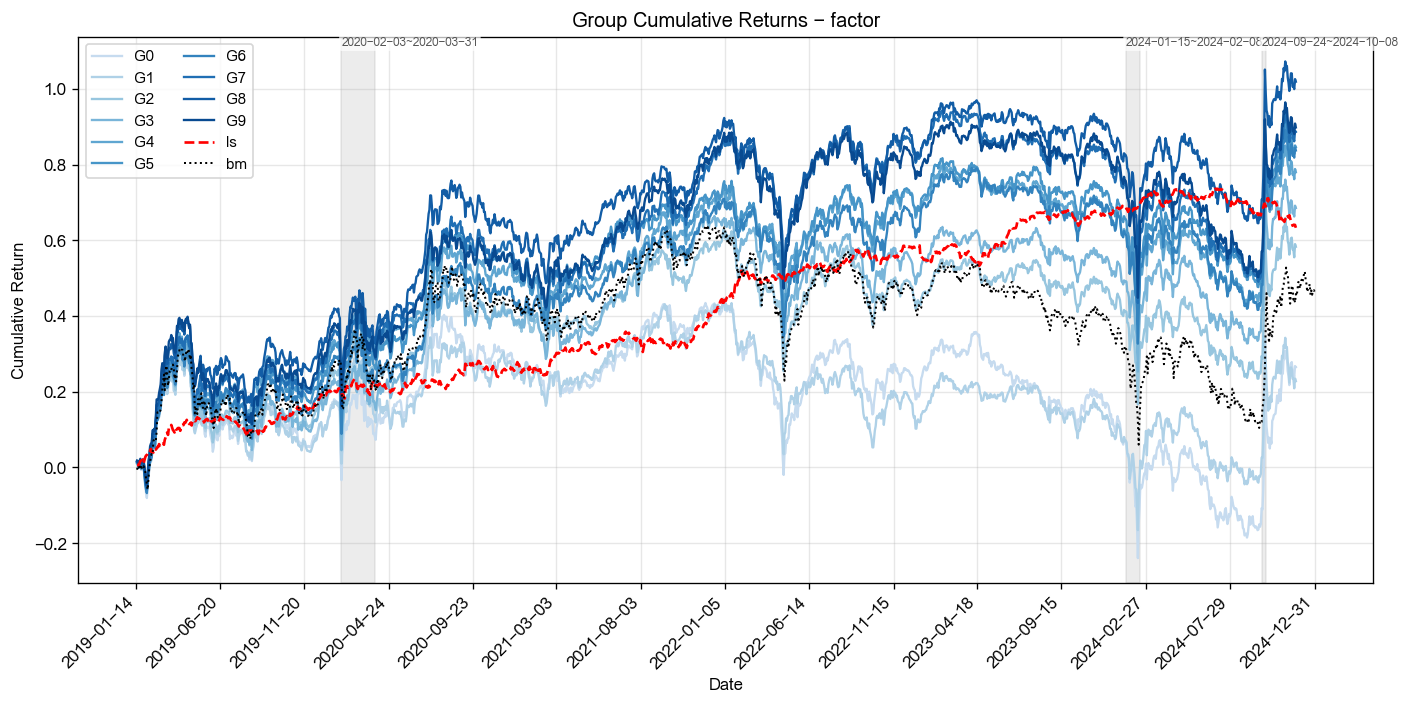
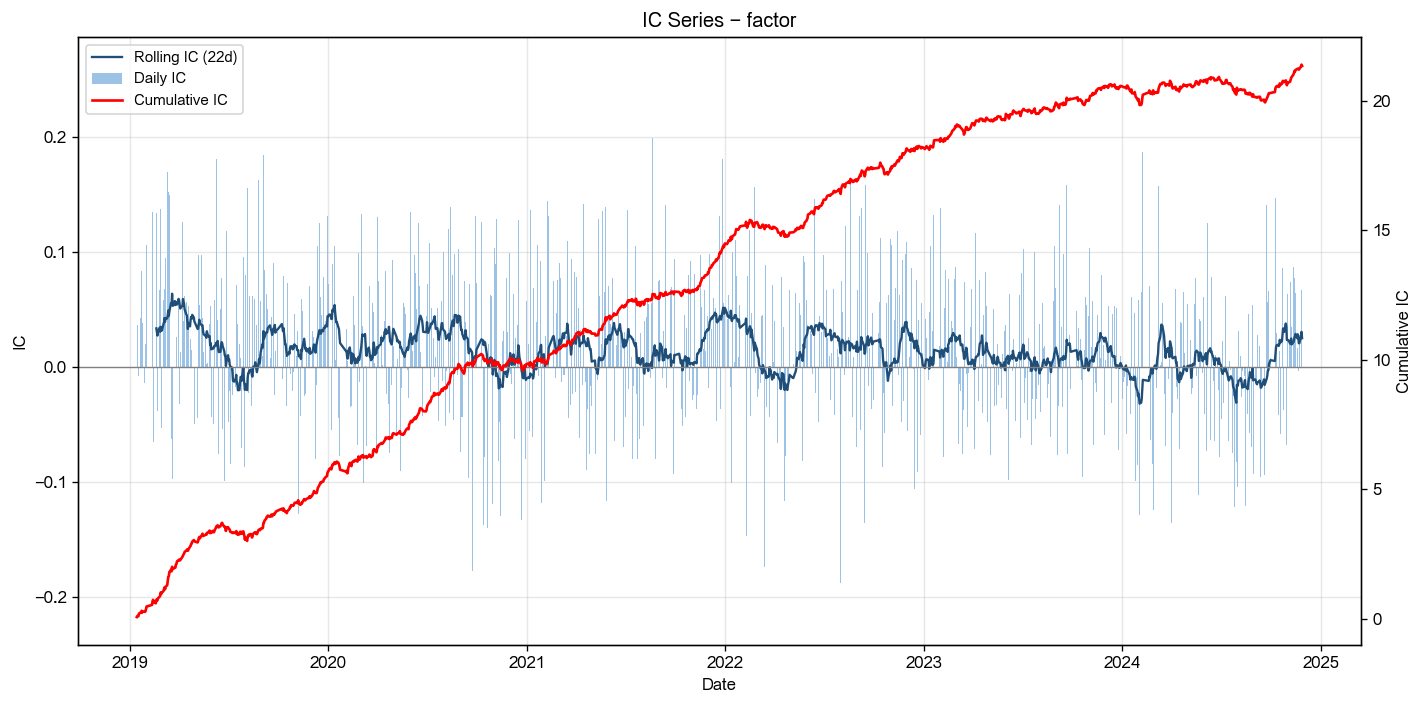
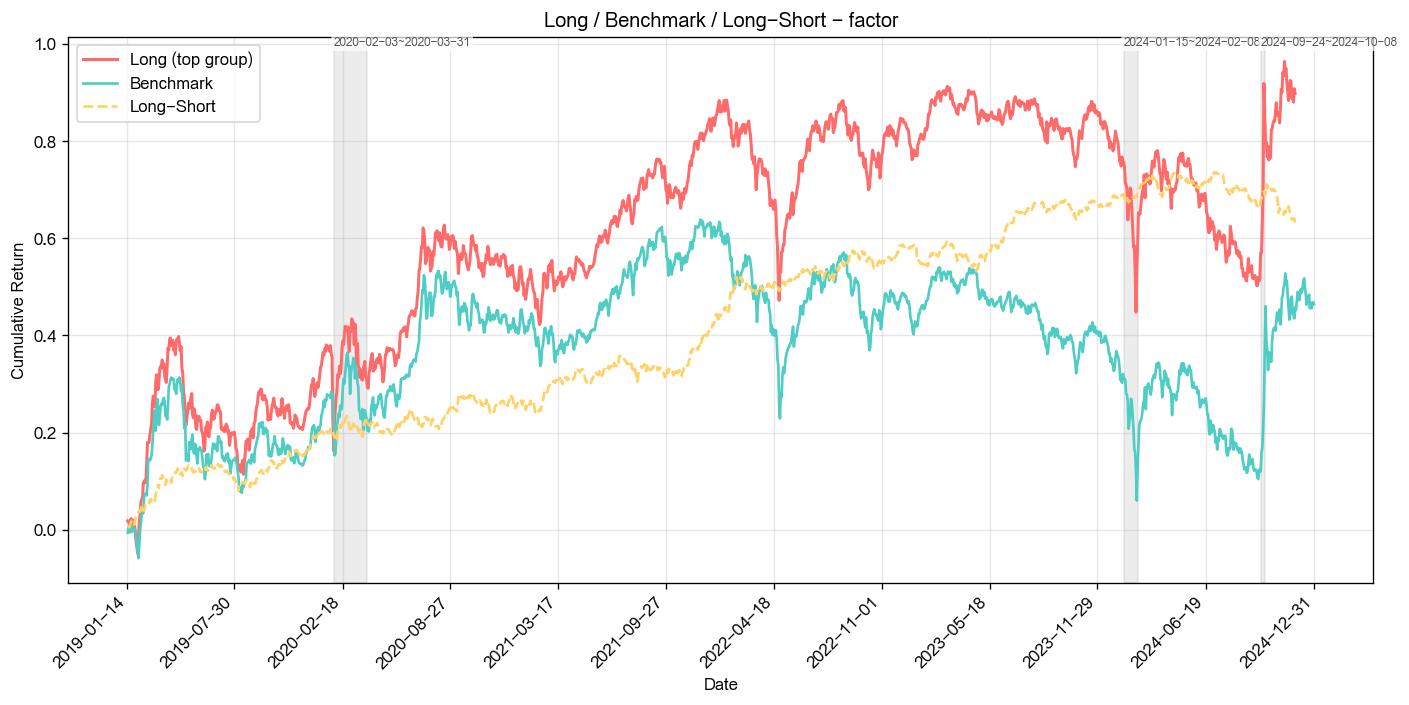
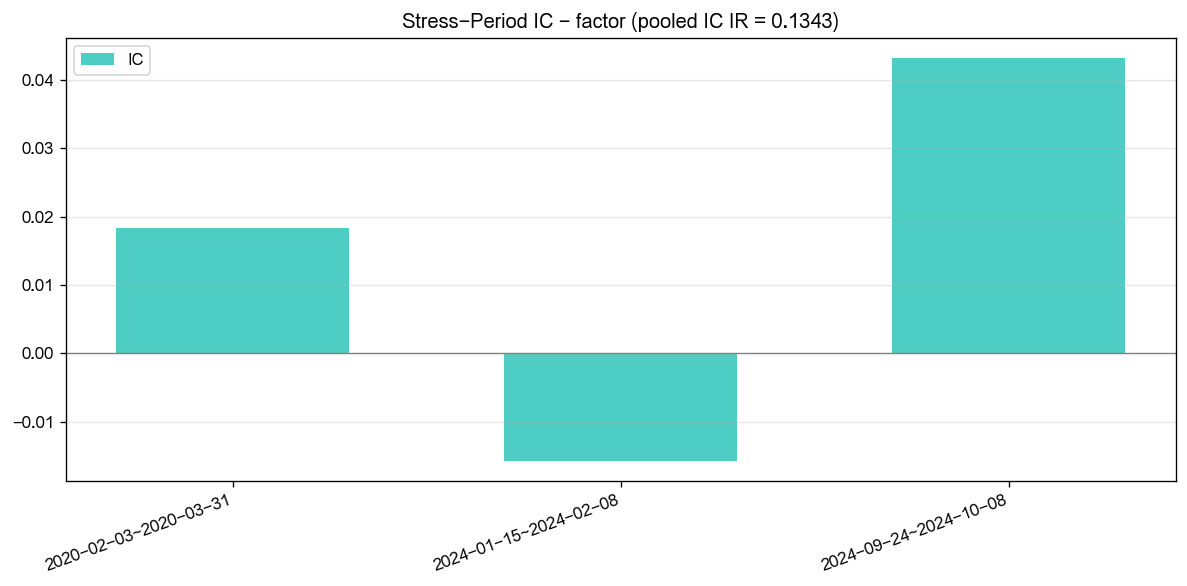
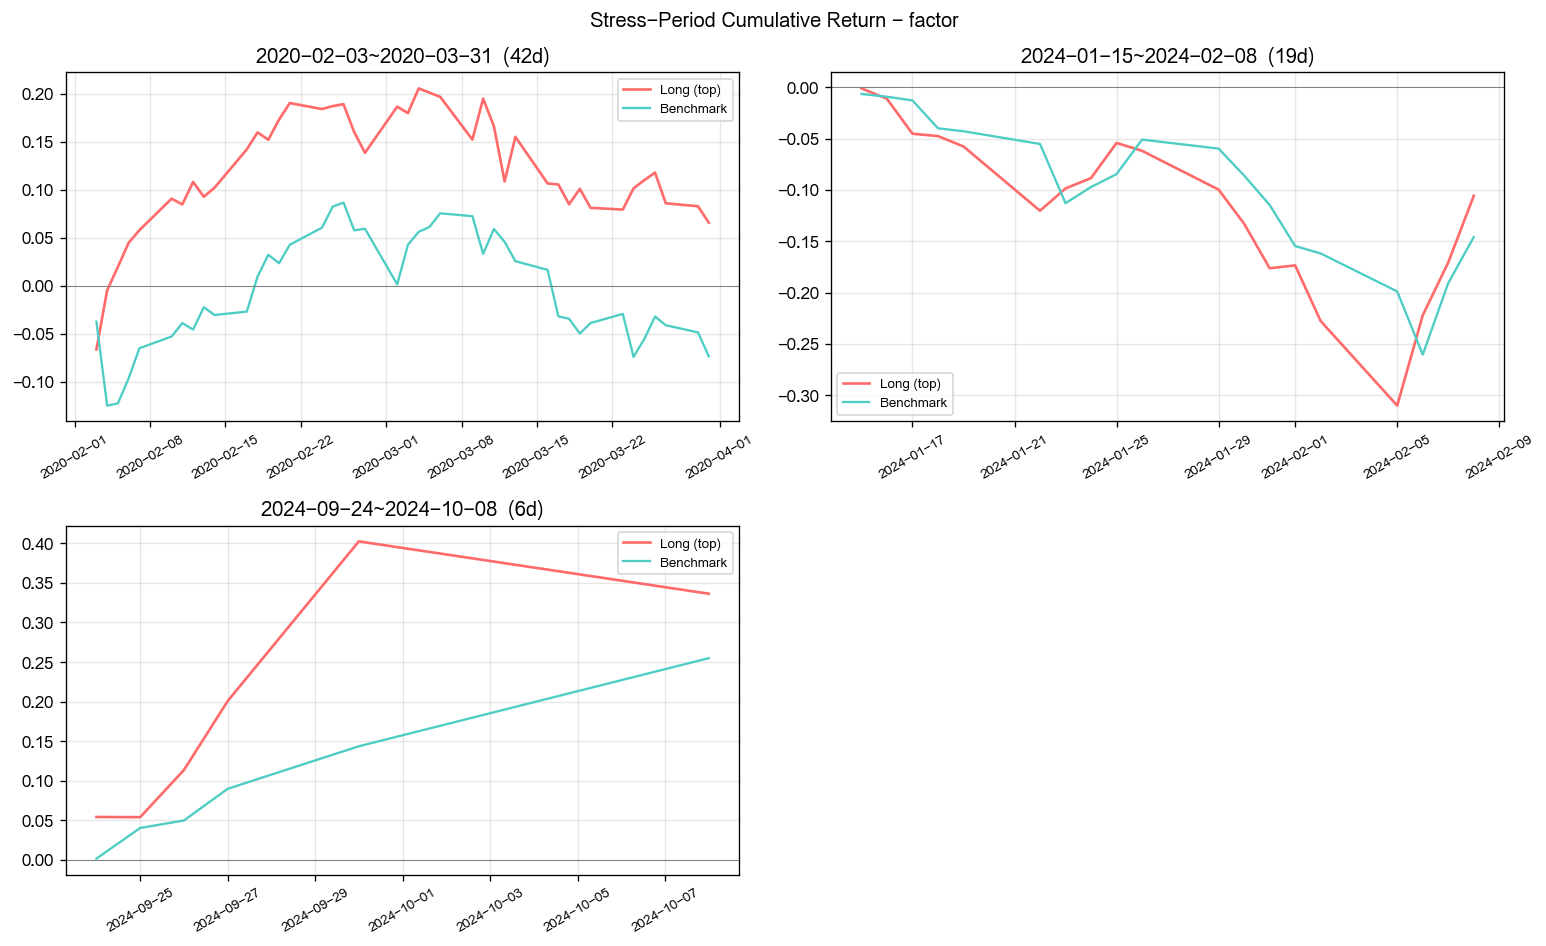

[2026-07-18 09:55:02] [info     ] ========== 因子池回归 ==========
[2026-07-18 09:55:03] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=2075 rows=2682900 start_date=2019-01-14
[2026-07-18 09:55:27] [info     ] 获取收益率数据, 耗时: 25.1338 秒
[2026-07-18 09:55:31] [info     ] 滚动 Elastic Net 拟合, 耗时: 3.1623 秒
[2026-07-18 09:55:31] [info     ] 统计 回归结果, 耗时: 0.0071 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,beta_000300SH_22,1.5087,0.0178,0.0118,0.9857
2,cci_14,1.4808,0.0291,0.0196,1.0000
3,turn,1.4629,0.0264,0.0180,0.9857
4,amount,1.3923,0.0213,0.0153,0.9571
5,list_days,1.3396,0.0105,0.0078,1.0000
6,net_active_buy_amount_main,1.3231,0.0168,0.0127,0.9857
7,debt_to_asset_lf,1.3029,0.0080,0.0062,0.9000
8,volatility_5,1.3001,0.0127,0.0097,0.9429
9,momentum_5,1.2746,0.0160,0.0125,0.9429
10,reversal_5,1.2618,0.0088,0.0070,0.9286

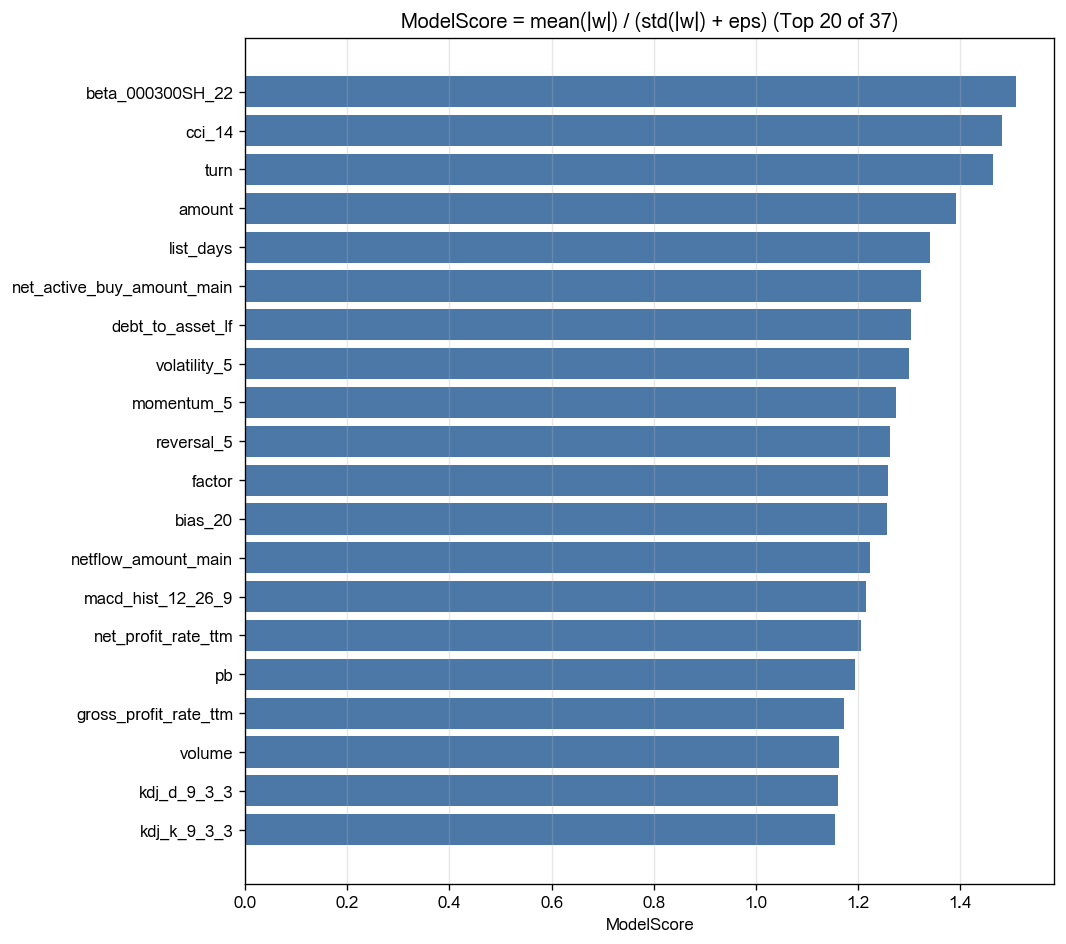
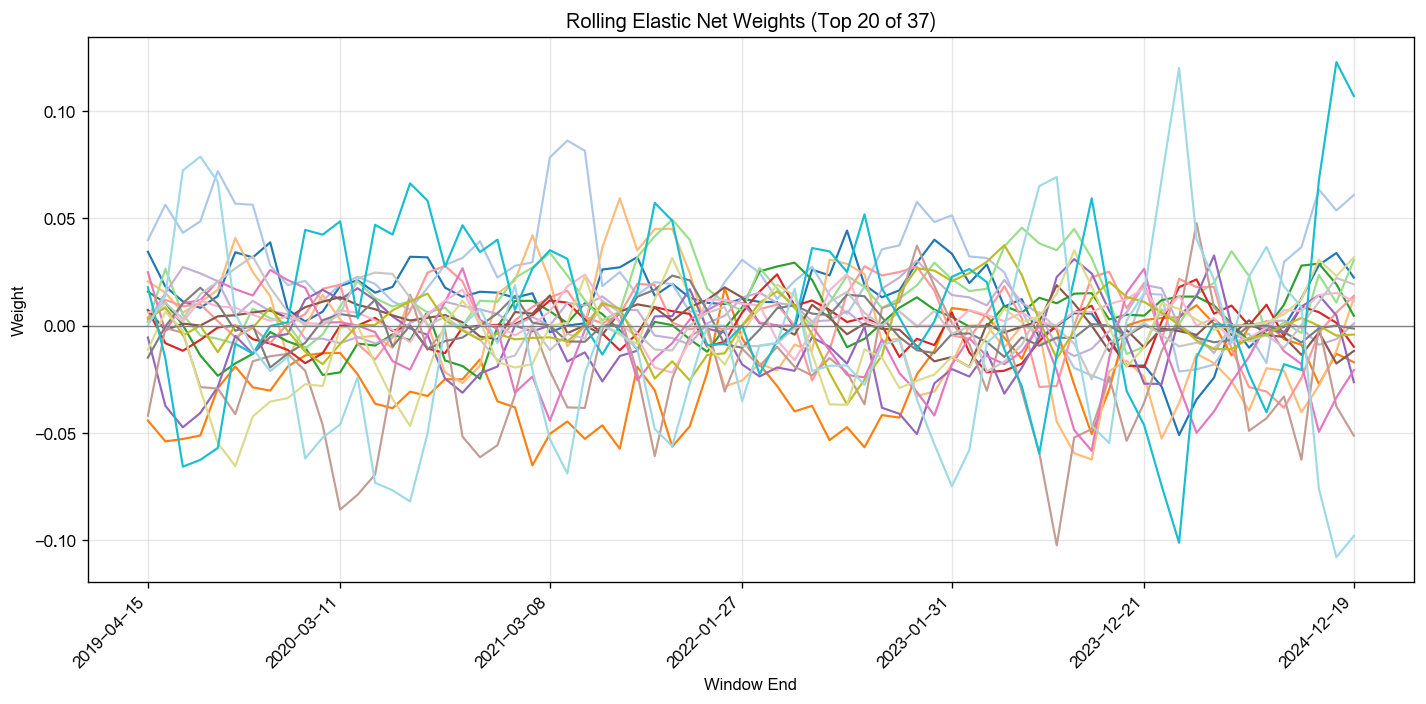
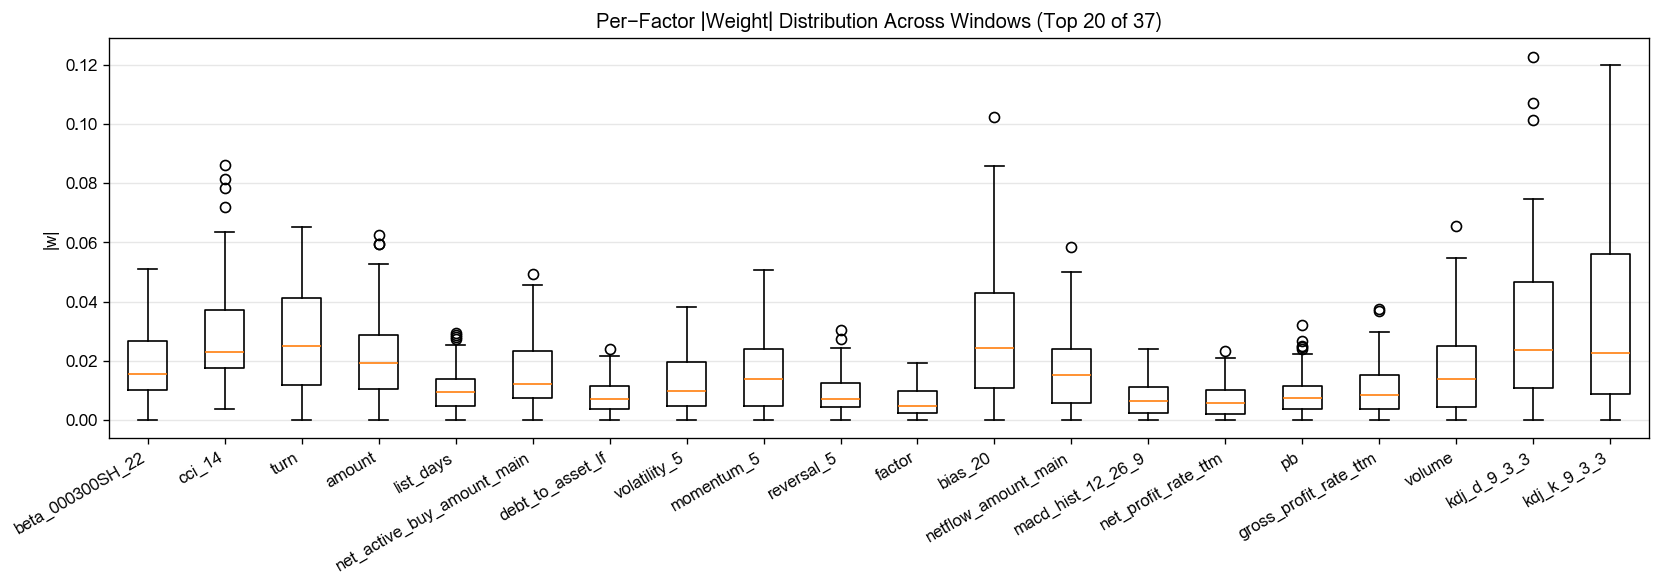
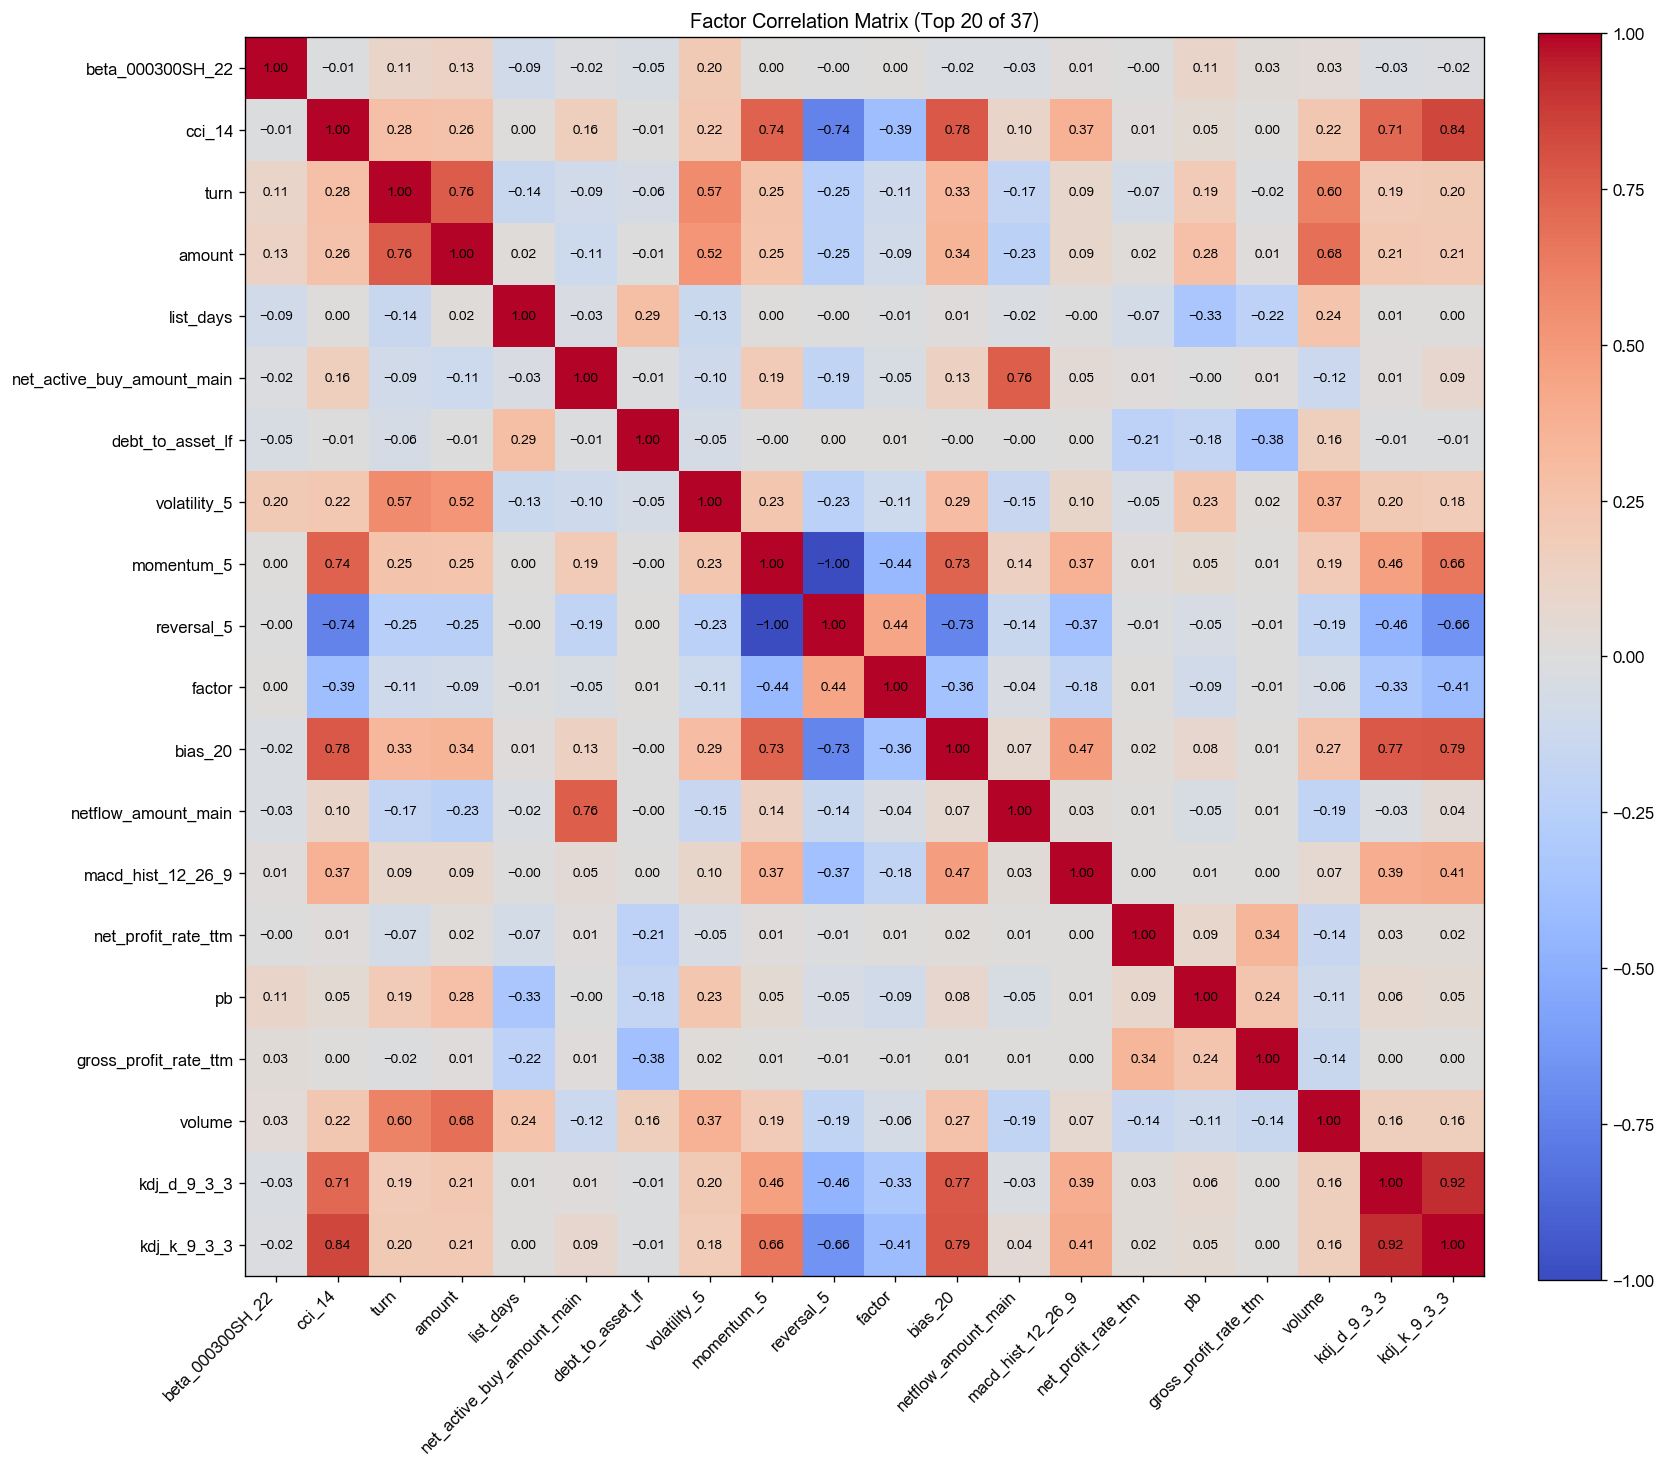

[2026-07-18 09:55:35] [warning  ] 返回的Outputs实例(size=203873351) 大于 64K, 将不会被缓存
[2026-07-18 09:55:35] [info     ] bigalpha_eval.v4 运行完成 [178.060s].


In [4]:
def main(datasources, start_date, end_date):
    """
    因子构建主函数
    """
    import pandas as pd
    import dai
    import numpy as np

    # 需要额外的 lookback 用于滚动计算和回测填充
    LOOKBACK_DAYS = 150
    query_start_date = pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)

    # ===== 从因子库读取 PS_TTM =====
    factorlib_table = 'bigalpha_2026_factorlib'
    
    sql = f"""
    SELECT date, instrument, ps_ttm
    FROM {factorlib_table}
    """
    df = dai.query(sql, filters={'date': [query_start_date, end_date]}).df()

    # 确保基础数据没有重复
    df = df.drop_duplicates(subset=['date', 'instrument'])

    # ===== 1. winsorize(PSTTM) - 截面去极值（5% 缩尾）=====
    def winsorize_series(s, lower=0.05, upper=0.95):
        q_lower = s.quantile(lower)
        q_upper = s.quantile(upper)
        return -s.clip(q_lower, q_upper)

    df['ps_ttm_winsor'] = df.groupby('date')['ps_ttm'].transform(
        lambda x: winsorize_series(x)
    )

    # ===== 2. ts_backfill(..., 120) - 向前填充 120 天 =====
    df = df.sort_values(['instrument', 'date'])
    df['ps_ttm_backfill'] = df.groupby('instrument')['ps_ttm_winsor'].transform(
        lambda x: x.ffill(limit=120)
    )

    # ===== 3. rank(...) - 截面排名（0-1 标准化）=====
    def rank_normalize(s):
        ranked = s.rank(method='average')
        return (ranked - 1) / (len(ranked) - 1) if len(ranked) > 1 else ranked * 0

    df['ps_ttm_rank'] = df.groupby('date')['ps_ttm_backfill'].transform(
        lambda x: rank_normalize(x)
    )

    # ===== 4. ts_rank(..., 5, 5) - 5 日滚动排名 =====
    def rolling_rank_func(x):
        """计算当前值在窗口中的排名分位数"""
        if len(x) < 5:
            return np.nan
        # x.iloc[-1] 是当前值，计算有多少个值小于当前值
        return (x < x.iloc[-1]).sum() / (len(x) - 1) if len(x) > 1 else 0.5

    df['ps_ttm_ts_rank'] = df.groupby('instrument')['ps_ttm_rank'].transform(
        lambda x: x.rolling(window=5, min_periods=5).apply(rolling_rank_func, raw=False)
    )

    # ===== 5. ts_mean(..., 5) - 5 日滚动均值 =====
    df['factor'] = df.groupby('instrument')['ps_ttm_ts_rank'].transform(
        lambda x: x.rolling(window=5, min_periods=5).mean()
    )

    # ===== 清理和输出 =====
    df = df[['date', 'instrument', 'factor']].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=['factor'])

    # 对齐时间区间
    df = df[(df['date'] >= pd.to_datetime(start_date)) & 
            (df['date'] <= pd.to_datetime(end_date))]

    # 最终去重和排序，确保索引唯一
    df = df.drop_duplicates(subset=['date', 'instrument'])
    df = df.sort_values(['date', 'instrument']).reset_index(drop=True)

    return df


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {'financial': 'bigalpha_2026_financial',}
    start_date = '2019-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )